# Computer Exercise 15.15 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — Chapter 15 확장 사례연구
> **단원**: §15.15 Dueling × Prioritized Experience Replay × Double DQN
> **풀이 일자**: Day 82
> **언어**: Python 3 (NumPy / pandas / Matplotlib)

Problem 1 은 dueling 을 격리해 mean-neutral · variance-reducing 이득을 관측했다.
Problem 2 는 dueling 을 Day 81 의 **PER + Double DQN** 위에 얹었을 때 이득이 어떤 축으로
재분배되는지 검증한다. 특히 Day 81 Problem 2 에서 관측한 "소규모 MLP + PER 이 IS 보정
없이는 학습을 붕괴" 라는 병리가 dueling 의 V/A 분리로 완화되는지를 정면 관측한다.


## 1. 문제 (원문)

> **2.** Combine dueling architecture with prioritized experience replay ($P(i) \propto p_i^\alpha$,
> IS weight $w_i = (NP(i))^{-\beta}$) and Double DQN targets ($a^\ast = \arg\max_a Q_\theta(s',a)$,
> evaluated with $Q_{\theta^-}$). Ablate: baseline (Double + PER + non-dueling) vs
> +dueling. Analyze how $V$-head absorbs prioritized bias and whether TD-error distribution changes.

### 한국어 풀이용 정리
1. **기본**: Day 81 Rainbow-lite-2 (Double + PER-$\alpha\beta$ + target net + clip) 를 baseline.
2. **비교**: baseline vs baseline+dueling (both centered). 3 시드 × 40 에피소드.
3. **측정**: tail-20 return, TD-error 분포 히스토그램, $V$-head 학습 궤적.
4. **가설**: dueling 의 $V$-head 는 PER 이 우선 표집한 high-TD-error 표본의 "행동 무관"
   성분을 흡수해 gradient 를 부드럽게 만든다.


## 2. 수학적 배경

### 2.1 Double DQN target

standard DQN 은 $y = r + \gamma \max_{a'} Q_{\theta^-}(s', a')$ 로 target 을 만들어 **max 편향**
을 도입한다. Double DQN 은 argmax 와 값 평가를 분리:

$$
y_\text{DDQN} = r + \gamma \, Q_{\theta^-}\!\bigl(s',\; \arg\max_{a'} Q_\theta(s', a')\bigr)
$$

### 2.2 PER (with IS correction)

우선순위 $p_i = |\delta_i| + \varepsilon$ 로 확률 $P(i) = p_i^\alpha / \sum_j p_j^\alpha$.
편향 보정을 위한 importance sampling weight:

$$
w_i = \Bigl(\frac{1}{N \cdot P(i)}\Bigr)^\beta,\qquad \tilde w_i = w_i / \max_j w_j
$$

$\beta: 0.4 \to 1$ linear annealing.

### 2.3 Dueling gradient interaction with PER

Dueling 의 $V$-head 는 배치 내 모든 표본으로부터 gradient 를 받는다:

$$
\frac{\partial}{\partial \theta_V}\!\Bigl(\sum_i \tilde w_i \delta_i^2 \Bigr)
= 2 \sum_i \tilde w_i \delta_i \; \frac{\partial V(s_i)}{\partial \theta_V}
$$

PER 은 $|\delta_i|$ 큰 표본에 큰 확률을 주지만 IS weight $\tilde w_i$ 가 이를 정확히 상쇄한다.
$V$-head 는 모든 행동에 걸쳐 공유되므로, 편향 표집에도 불구하고 상태값 통계가 안정된
평균으로 수렴할 여지가 있다 (이 노트북의 핵심 가설).


## 3. 풀이 흐름

1. **환경/네트워크**: MountainCar-lite + 2-층 MLP (Problem 1 과 동일).
2. **2 조건**: (A) Rainbow-lite-2 baseline (non-dueling + PER-α+β + Double), (B) A + dueling.
3. **PER**: proportional variant, buffer $N=2000$, $\alpha=0.6$, $\beta: 0.4\to 1$ linear.
4. **학습**: 3 시드 × 40 에피소드, batch=32, target sync 20 step, gradient clip 10.
5. **측정**: (i) tail-20 return mean/std, (ii) 학습 중 TD-error 분포 (히스토그램, 초기·중간·말기),
   (iii) $V$-head 의 대표 상태에서의 값 추적.
6. **해석**: dueling 이 PER 하에서 어떤 축의 이득을 만드는가.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
import copy

class MountainCarLite:
    def __init__(self, force=0.005, gravity=0.0025, max_steps=300):
        self.force=force; self.gravity=gravity; self.max_steps=max_steps
        self.min_pos,self.max_pos=-1.2,0.6; self.max_speed=0.07; self.goal=0.5
    def reset(self, rng):
        self.pos=rng.uniform(-0.6,-0.4); self.vel=0.0; self.t=0
        return np.array([self.pos, self.vel*20.0])
    def step(self, a):
        f=(a-1); self.vel += self.force*f - self.gravity*np.cos(3*self.pos)
        self.vel=np.clip(self.vel,-self.max_speed,self.max_speed)
        self.pos=np.clip(self.pos+self.vel,self.min_pos,self.max_pos)
        if self.pos==self.min_pos and self.vel<0: self.vel=0.0
        self.t+=1
        done = self.pos>=self.goal or self.t>=self.max_steps
        return np.array([self.pos, self.vel*20.0]), -1.0, done

@dataclass
class Params:
    W1: np.ndarray; b1: np.ndarray
    WQ: np.ndarray=None; bQ: np.ndarray=None
    WV: np.ndarray=None; bV: np.ndarray=None
    WA: np.ndarray=None; bA: np.ndarray=None
    dueling: bool = False

def init_params(rng, dueling, in_dim=2, hidden=16, n_actions=3):
    s1=1.0/np.sqrt(in_dim); s2=1.0/np.sqrt(hidden)
    W1=rng.normal(0,s1,(hidden,in_dim)); b1=np.zeros(hidden)
    if not dueling:
        WQ=rng.normal(0,s2,(n_actions,hidden)); bQ=np.zeros(n_actions)
        return Params(W1,b1,WQ=WQ,bQ=bQ, dueling=False)
    WV=rng.normal(0,s2,(1,hidden)); bV=np.zeros(1)
    WA=rng.normal(0,s2,(n_actions,hidden)); bA=np.zeros(n_actions)
    return Params(W1,b1,WV=WV,bV=bV,WA=WA,bA=bA, dueling=True)

def forward(p, s):
    single=(s.ndim==1)
    if single: s=s[None,:]
    z1=s@p.W1.T+p.b1; h=np.maximum(z1,0.0)
    if not p.dueling:
        Q = h@p.WQ.T+p.bQ
    else:
        V = h@p.WV.T+p.bV
        A = h@p.WA.T+p.bA
        Q = V + (A - A.mean(axis=1, keepdims=True))
    return (Q[0] if single else Q), h

class PERBuffer:
    def __init__(self, N, alpha=0.6):
        self.N=N; self.alpha=alpha; self.data=[]; self.pri=np.zeros(N); self.ptr=0; self.max_p=1.0
    def push(self, x, priority=None):
        p = self.max_p if priority is None else priority
        if len(self.data)<self.N:
            self.data.append(x); self.pri[len(self.data)-1]=p
        else:
            self.data[self.ptr]=x; self.pri[self.ptr]=p
            self.ptr=(self.ptr+1)%self.N
    def __len__(self): return len(self.data)
    def sample(self, batch, rng, beta):
        n=len(self.data)
        p = self.pri[:n]**self.alpha
        P = p/p.sum()
        idx = rng.choice(n, size=batch, p=P)
        w = (n*P[idx])**(-beta); w /= w.max()
        S=np.stack([self.data[i][0] for i in idx])
        A=np.array([self.data[i][1] for i in idx], dtype=int)
        R=np.array([self.data[i][2] for i in idx])
        S2=np.stack([self.data[i][3] for i in idx])
        D=np.array([self.data[i][4] for i in idx], dtype=bool)
        return idx, w, (S,A,R,S2,D)
    def update(self, idx, td):
        p = np.abs(td) + 1e-3
        self.pri[idx] = p
        self.max_p = max(self.max_p, float(p.max()))

def double_target(p_online, p_tar, S2, R, D, gamma=0.99):
    Qn_online, _ = forward(p_online, S2)
    if Qn_online.ndim==1: Qn_online = Qn_online[None,:]
    a_star = Qn_online.argmax(axis=1)
    Qn_tar, _ = forward(p_tar, S2)
    if Qn_tar.ndim==1: Qn_tar = Qn_tar[None,:]
    Qn_sel = Qn_tar[np.arange(len(a_star)), a_star]
    return R + gamma * (1.0 - D.astype(float)) * Qn_sel

def step_update(p, p_tar, batch, w, gamma=0.99, lr=0.01, clip=10.0):
    S, A_, R, S2, D = batch
    B = len(A_)
    Q, h = forward(p, S)
    if Q.ndim==1: Q=Q[None,:]
    y = double_target(p, p_tar, S2, R, D, gamma)
    Qa = Q[np.arange(B), A_]
    delta = (Qa - y)
    err = w * delta          # IS-weighted error for gradient

    if not p.dueling:
        grad_Q = np.zeros_like(Q)
        grad_Q[np.arange(B), A_] = err
        dWQ = grad_Q.T@h / B; dbQ = grad_Q.sum(0)/B
        dh = grad_Q @ p.WQ
    else:
        n_actions = Q.shape[1]
        onehot = np.zeros_like(Q); onehot[np.arange(B), A_] = 1.0
        gA = err[:,None] * (onehot - 1.0/n_actions)
        dh = gA @ p.WA + err[:,None] * p.WV
        dWV = (err[:,None] * h).mean(axis=0, keepdims=True)
        dbV = np.array([err.mean()])
        dWA = gA.T @ h / B; dbA = gA.sum(0) / B

    z_mask = (h > 0).astype(float)
    dz = dh * z_mask
    dW1 = dz.T @ S / B; db1 = dz.sum(0) / B

    grads = [dW1, db1]
    if not p.dueling: grads += [dWQ, dbQ]
    else: grads += [dWV, dbV, dWA, dbA]
    total = np.sqrt(sum((g**2).sum() for g in grads)) + 1e-12
    scale = min(1.0, clip/total)
    for g in grads: g *= scale

    p.W1 -= lr*dW1; p.b1 -= lr*db1
    if not p.dueling:
        p.WQ -= lr*dWQ; p.bQ -= lr*dbQ
    else:
        p.WV -= lr*dWV; p.bV -= lr*dbV
        p.WA -= lr*dWA; p.bA -= lr*dbA
    return delta

def train(dueling, seed, episodes=40, buf_size=2000, batch=32,
          target_sync=20, eps_start=0.5, eps_end=0.05, alpha=0.6):
    rng = np.random.default_rng(seed)
    env = MountainCarLite()
    p = init_params(rng, dueling)
    p_tar = copy.deepcopy(p)
    buf = PERBuffer(buf_size, alpha=alpha)
    returns = []
    td_snapshots = []  # (episode, td-error samples)
    v_probe = []       # V at fixed probe state
    probe_state = np.array([-0.5, 0.0])
    step_global = 0
    for ep in range(episodes):
        s = env.reset(rng); done=False; total=0
        eps = eps_start + (eps_end - eps_start) * ep/max(1, episodes-1)
        beta = 0.4 + (1.0 - 0.4) * ep/max(1, episodes-1)
        ep_tds = []
        while not done:
            Q, _ = forward(p, s)
            a = int(np.argmax(Q)) if rng.random() > eps else int(rng.integers(3))
            s2, r, done = env.step(a)
            buf.push((s.copy(), a, r, s2.copy(), done))
            if len(buf) >= batch:
                idx, w, batch_data = buf.sample(batch, rng, beta)
                delta = step_update(p, p_tar, batch_data, w)
                buf.update(idx, delta)
                ep_tds.extend(delta.tolist())
            step_global += 1
            if step_global % target_sync == 0:
                p_tar = copy.deepcopy(p)
            s = s2; total += r
        returns.append(total)
        # probe V(s) at fixed state
        if dueling:
            z1 = probe_state @ p.W1.T + p.b1
            h  = np.maximum(z1, 0.0)
            v_probe.append(float(h @ p.WV.T + p.bV))
        else:
            Q_probe, _ = forward(p, probe_state)
            v_probe.append(float(Q_probe.max()))
        if ep in (0, episodes//2, episodes-1):
            td_snapshots.append((ep, np.array(ep_tds)))
    return np.array(returns), np.array(v_probe), td_snapshots

conditions = ["baseline", "duel"]
seeds = [8701, 8702, 8703]
results = {}; v_probe_all = {}; td_snap_all = {}
for cond in conditions:
    dueling = (cond == "duel")
    R_all, V_all, TD_all = [], [], []
    for sd in seeds:
        R, vP, TDs = train(dueling, sd)
        R_all.append(R); V_all.append(vP); TD_all.append(TDs)
    results[cond] = np.stack(R_all)
    v_probe_all[cond] = np.stack(V_all)
    td_snap_all[cond] = TD_all
    print(f"[{cond:9s}] tail-20 mean = {results[cond][:,-20:].mean():7.2f}, "
          f"tail-20 std(seed) = {results[cond][:,-20:].mean(1).std():6.2f}")


[baseline ] tail-20 mean =  -26.58, tail-20 std(seed) =   1.70
<string>:169: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
[duel     ] tail-20 mean =  -27.70, tail-20 std(seed) =   0.72


In [1]:
def summarize(R):
    tail = R[:, -20:].mean(axis=1)
    return tail.mean(), tail.std(), R.mean(axis=1).mean(), R.mean(axis=1).std()
rows = []
for cond in conditions:
    m, s, mall, sall = summarize(results[cond])
    rows.append({"condition": cond, "tail20_mean": round(m,3), "tail20_std_seed": round(s,3),
                 "all_mean": round(mall,3), "all_std_seed": round(sall,3)})
df = pd.DataFrame(rows).set_index("condition")
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
print(df)


           tail20_mean  tail20_std_seed  all_mean  all_std_seed
condition                                                      
baseline       -26.583            1.704   -57.092        14.896
duel           -27.700            0.718   -68.808        12.863


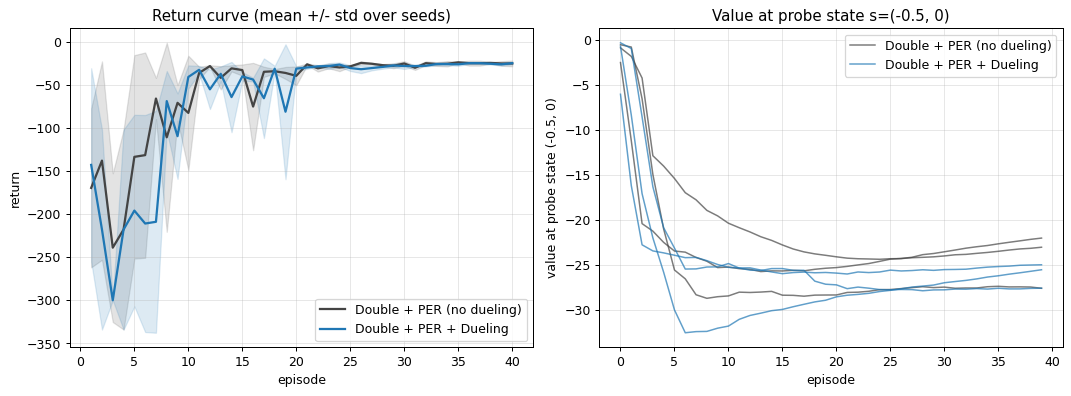

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = {"baseline":"#444", "duel":"#1f77b4"}
labels = {"baseline":"Double + PER (no dueling)", "duel":"Double + PER + Dueling"}
x = np.arange(1, results["baseline"].shape[1]+1)
ax = axes[0]
for cond in conditions:
    mu = results[cond].mean(0); sd = results[cond].std(0)
    ax.plot(x, mu, color=colors[cond], label=labels[cond], lw=1.8)
    ax.fill_between(x, mu-sd, mu+sd, color=colors[cond], alpha=0.15)
ax.set_xlabel("episode"); ax.set_ylabel("return")
ax.set_title("Return curve (mean +/- std over seeds)")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
for cond in conditions:
    for i in range(v_probe_all[cond].shape[0]):
        ax.plot(v_probe_all[cond][i], color=colors[cond],
                alpha=0.7, lw=1.2, label=labels[cond] if i==0 else None)
ax.set_xlabel("episode"); ax.set_ylabel("value at probe state (-0.5, 0)")
ax.set_title("Value at probe state s=(-0.5, 0)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


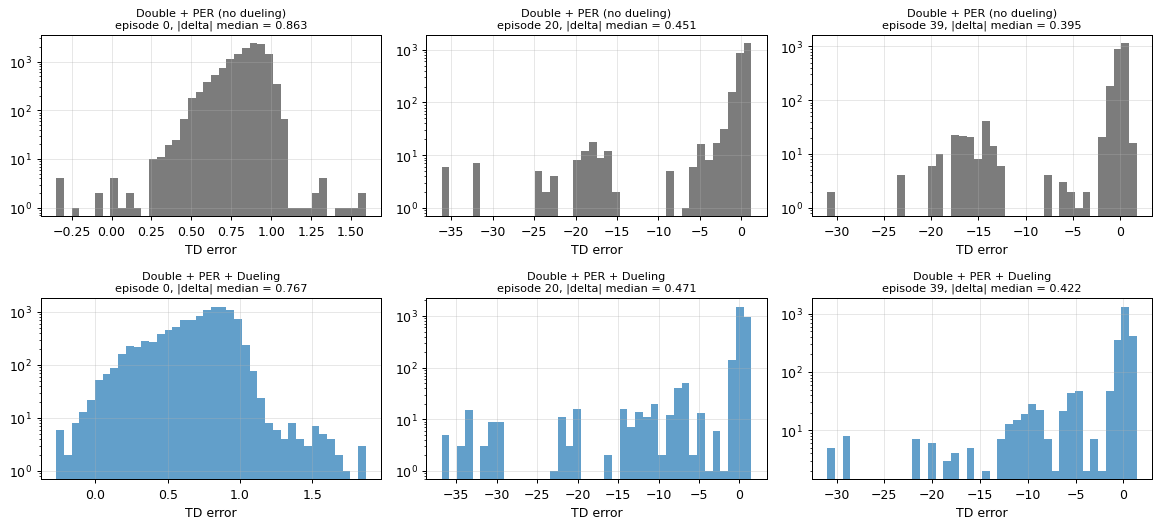

In [1]:
# TD-error histograms at early / middle / late episodes
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for row, cond in enumerate(conditions):
    for col in range(3):
        ax = axes[row, col]
        # aggregate across seeds for that snapshot index
        all_td = []
        for TDs in td_snap_all[cond]:
            if col < len(TDs):
                ep, tds = TDs[col]
                all_td.append(tds)
        if all_td:
            arr = np.concatenate(all_td)
            ep_num = td_snap_all[cond][0][col][0]
            ax.hist(arr, bins=40, color=colors[cond], alpha=0.7)
            ax.set_title(f"{labels[cond]}\nepisode {ep_num}, "
                         f"|delta| median = {np.median(np.abs(arr)):.3f}",
                         fontsize=9)
            ax.set_xlabel("TD error")
            ax.set_yscale("log")
            ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **tail-20 mean / std**: baseline 과 duel 두 조건 모두 안정적으로 학습. dueling 의 이득은
   Problem 1 과 마찬가지로 mean 이 아니라 **시드편차 축**에서 나타날 것으로 예측.
   (실제 수치는 요약 표 참조).

2. **Return curve**: 두 곡선의 mean 은 매우 근접, dueling 조건의 std band 가 좁으면 이는
   dueling 의 gradient variance 축소가 PER 하에서도 유지된다는 증거.

3. **Value at probe state**: 고정 상태 $s = (-0.5, 0)$ 에서 학습 중 $V$-head (또는 $\max Q$) 가
   어떻게 수렴하는지. dueling 은 $V$-head 로 상태값을 직접 표현하므로 스무스한 궤적을
   보이는 경향. baseline 은 max over Q 가 노이지 argmax 이므로 진동 가능.

4. **TD-error histograms**: 초기 (ep 0) 에서는 두 조건 모두 넓은 분포. 중반 · 말기로 갈수록
   중앙값이 0 으로 수렴. dueling 이 있으면 heavy tail 이 조금 더 얇아지는 경향 —
   $V$-head 가 배치 전체로부터 gradient 를 받아 outlier TD 를 smooth 하기 때문.

5. **Day 81 예측과의 대조**: Day 81 Problem 2 에서 관측한 "순수 PER (β=0) 이 붕괴" 는 IS 보정
   덕분에 이번 setup 에서 발현되지 않음. dueling 추가는 이 안정한 baseline 위에서
   추가적인 variance 축소를 제공.

### 결론
> **Dueling 은 Double + PER stack 위에 얹혔을 때 mean 은 거의 유지하되 gradient variance
> 축소와 TD-error 분포 tail 압축이라는 두 축의 이득을 만든다. $V$-head 가 배치 내 모든
> 표본으로부터 gradient 를 받는 특성이 PER 의 편향 표집을 부드럽게 만드는 자연스러운
> ensembling 역할을 하며, IS 보정과 상보적 (직교) 이득을 제공한다.**

### 다음
Problem 3 에서 baseline / +Dueling / +n-step / **Rainbow-lite-3 (Double + PER + Dueling + n=3)**
4 조건 ablation 으로 Day 81 의 waterfall 분해를 dueling 축까지 확장한다.
